In [2]:
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore (1).csv


In [3]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# display settings
pd.set_option('display.max_columns', None)

In [4]:
#Load dataset
df = pd.read_csv('SampleSuperstore.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [6]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
df = df.drop_duplicates()

In [8]:
#Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [9]:
#Create Month & Year columns
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

In [11]:
#Basic KPIs
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)

Total Sales: 2261536.7827000003
Total Orders: 4922


In [13]:
#Sales by Category
sales_category = df.groupby('Category')['Sales'].sum()
sales_category

,Sales
Category,
Furniture,728658.5757
Office Supplies,705422.3340
Technology,827455.8730


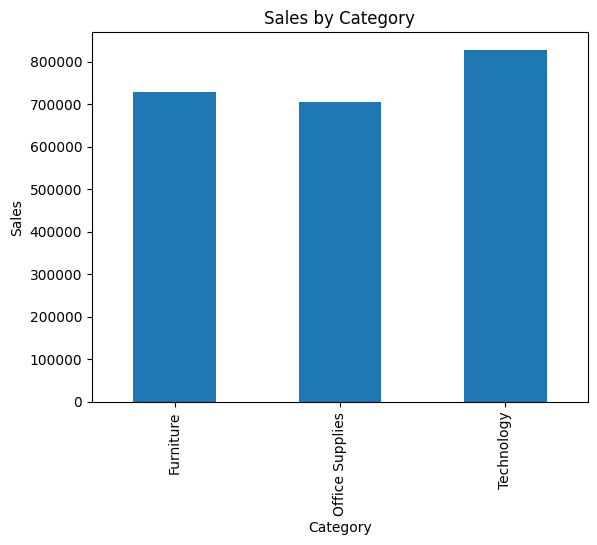

In [15]:
sales_category.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

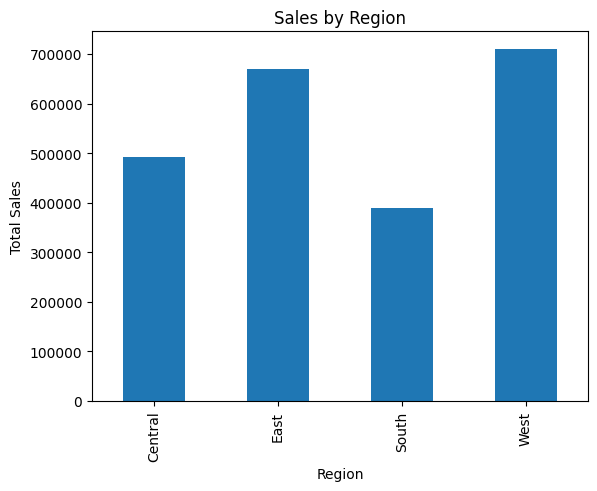

In [16]:
#Sales by Region
sales_region = df.groupby('Region')['Sales'].sum()

sales_region.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

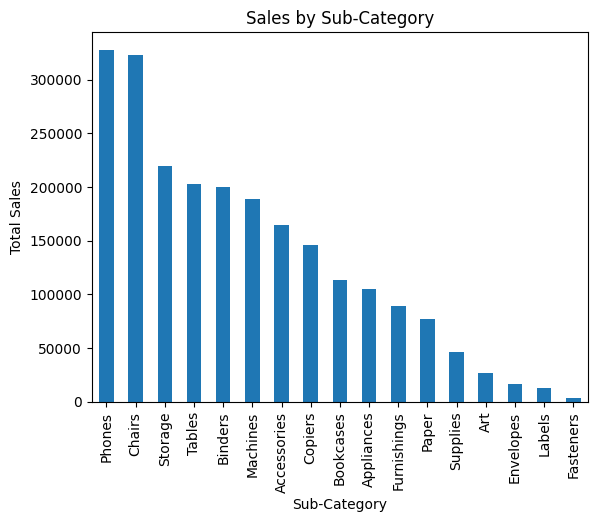

In [17]:
#Sales by Sub-Category (very important insight)
sales_subcategory = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

sales_subcategory.plot(kind='bar')

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.show()

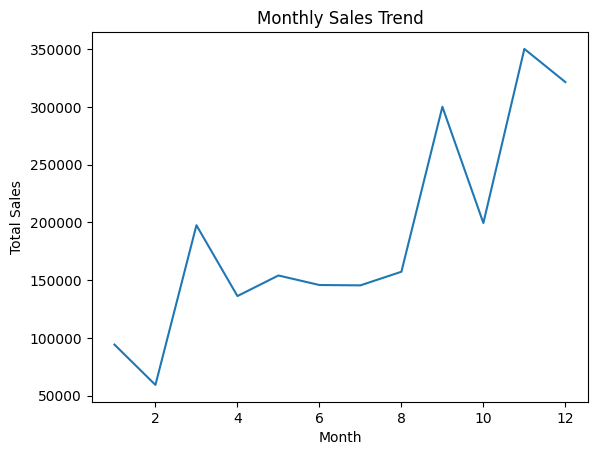

In [18]:
#Monthly Sales Trend
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

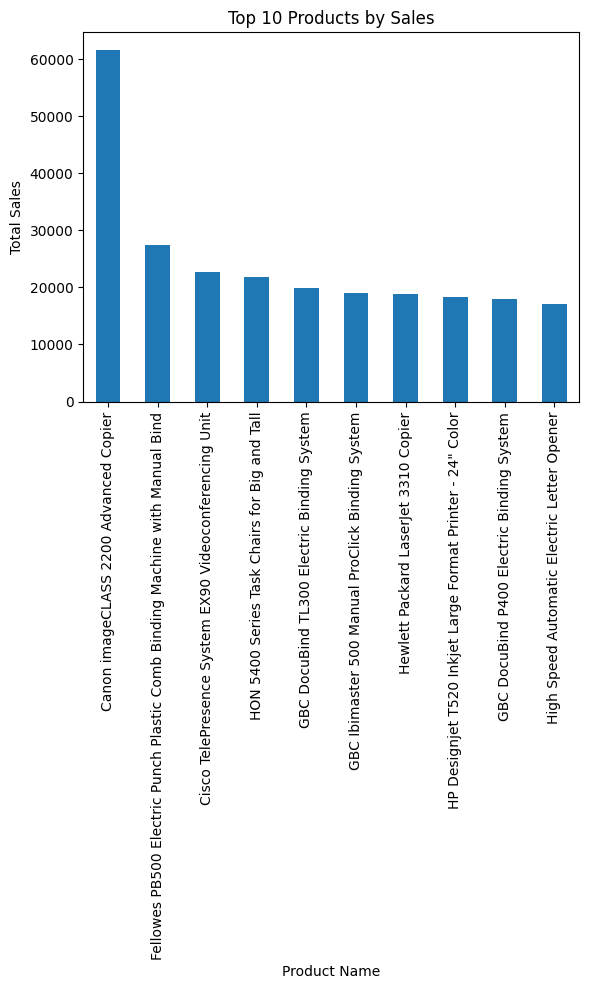

In [19]:
#Top 10 Products by Sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")

plt.show()

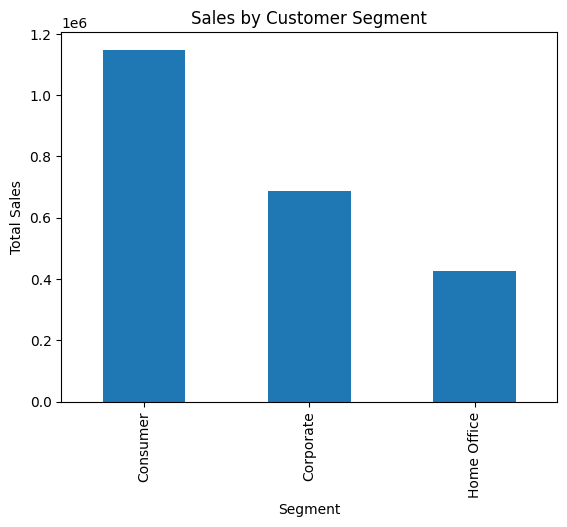

In [20]:
#Sales by Customer Segment
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='bar')

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.show()

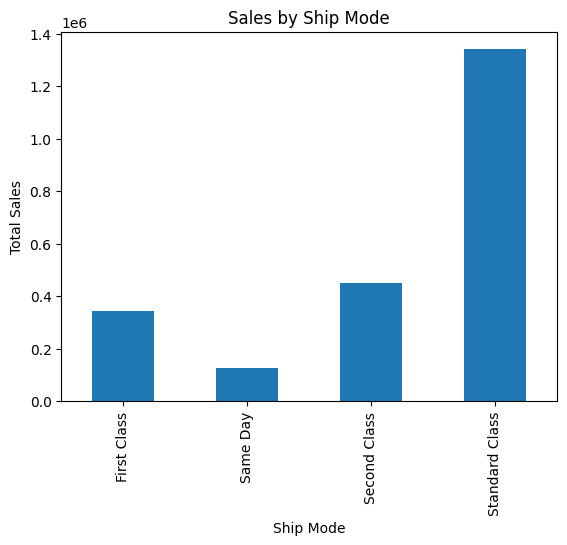

In [21]:
#Sales by Ship Mode
ship_sales = df.groupby('Ship Mode')['Sales'].sum()

ship_sales.plot(kind='bar')

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")

plt.show()

In [22]:
#Feature Engineering
df['Year'] = df['Order Date'].dt.year
df['Month Name'] = df['Order Date'].dt.month_name()

In [23]:
df[['Order Date','Year','Month Name']].head()

,Order Date,Year,Month Name
0,2017-11-08,2017,November
1,2017-11-08,2017,November
2,2017-06-12,2017,June
3,2016-10-11,2016,October
4,2016-10-11,2016,October


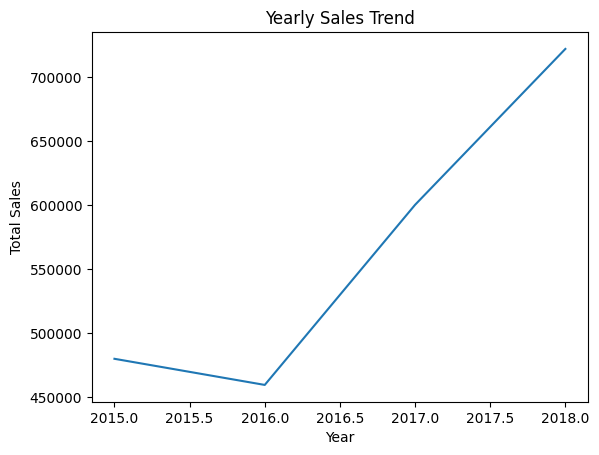

In [24]:
#Yearly Sales Trend
yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales.plot()

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

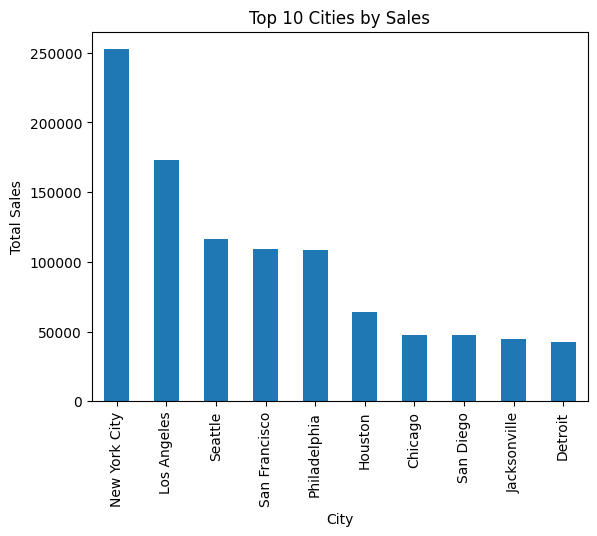

In [25]:
#Top 10 Cities by Sales
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind='bar')

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.show()

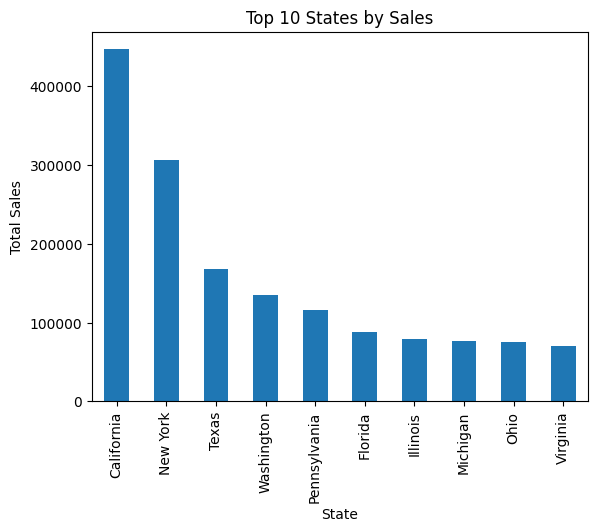

In [26]:
#State wise sales
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar')

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.show()

In [27]:
#Average Sales per Order
avg_sales_order = df.groupby('Order ID')['Sales'].sum().mean()

print("Average Sales per Order:", avg_sales_order)

Average Sales per Order: 459.4751691791955


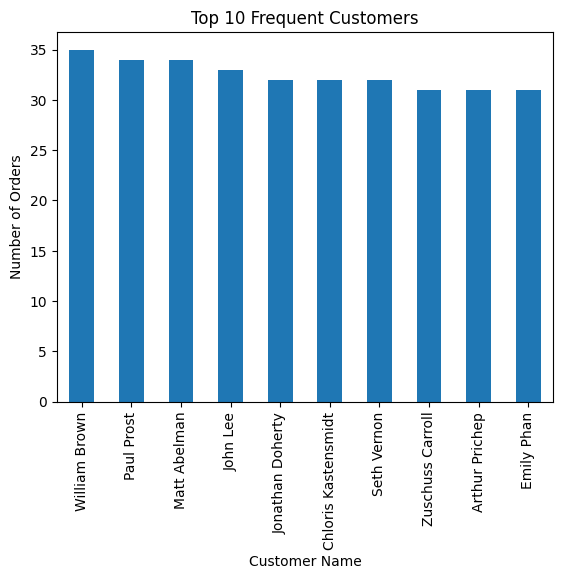

In [28]:
#Most frequent customers
top_customers = df['Customer Name'].value_counts().head(10)

top_customers.plot(kind='bar')

plt.title("Top 10 Frequent Customers")
plt.xlabel("Customer Name")
plt.ylabel("Number of Orders")

plt.show()

In [29]:
#Correlation insight
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Month', 'Year', 'Month Name'],
      dtype='object')


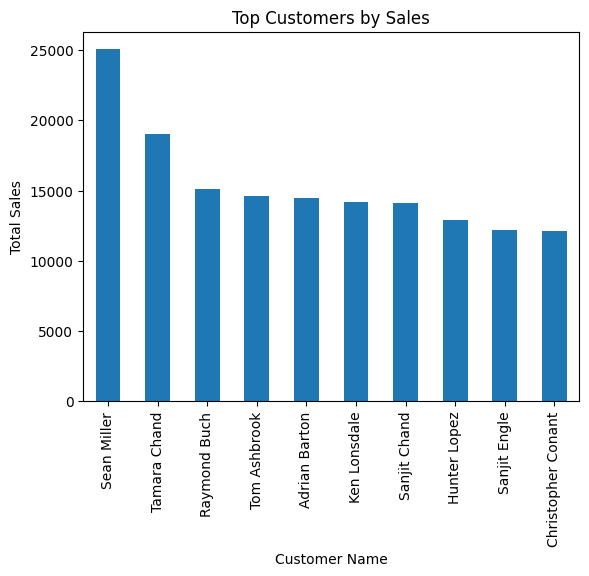

In [30]:
#Average Sales per Customer
customer_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

customer_sales.plot(kind='bar')

plt.title("Top Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")

plt.show()

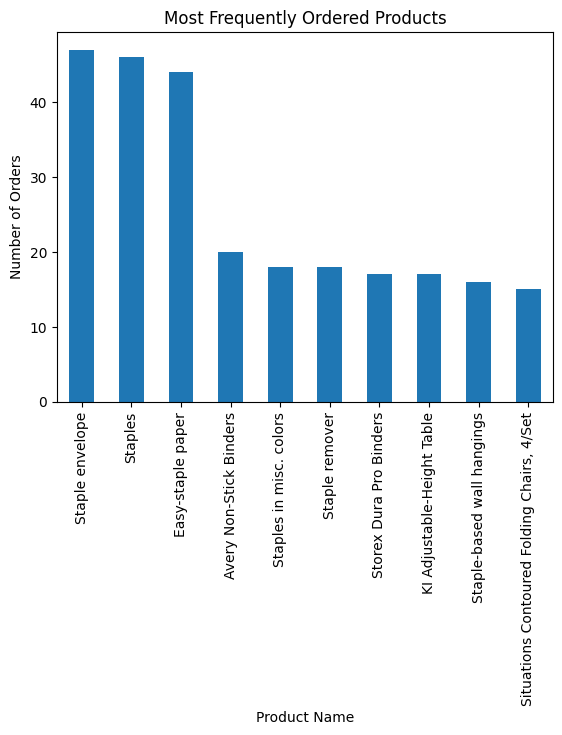

In [31]:
#Most popular products (based on number of orders)
popular_products = df['Product Name'].value_counts().head(10)

popular_products.plot(kind='bar')

plt.title("Most Frequently Ordered Products")
plt.xlabel("Product Name")
plt.ylabel("Number of Orders")

plt.show()